<a id="top"></a>
# Chapter 4 — Fitting neutron F(Q) and G(r) with RMCProfile

**Reverse Monte Carlo with RMCProfile — from the pair distribution function to a refined box** · chapter 4 of 10

[◀ 3 Starting configurations and the rmc6f file](RMCProfile_03_Starting_Configurations.ipynb) · [Contents of the book](README.md) · [5 X-ray data and the Bragg profile ▶](RMCProfile_05_Xray_and_Bragg.ipynb)

**In this chapter**

- [§14 Synthetic "data" with a known answer](#sec-14)
- [§15 One pass: RMCProfile computes what we compute](#sec-15)
- [§16 The refinement](#sec-16)
- [§17 `CONVOLVE ::` and the finite box](#sec-17)
- [§18 The same data through `rmclite`](#sec-18)

All chapters: [0](RMCProfile_00_Introduction.ipynb) · [1](RMCProfile_01_Total_Scattering_and_the_PDF.ipynb) · [2](RMCProfile_02_The_RMC_Algorithm.ipynb) · [3](RMCProfile_03_Starting_Configurations.ipynb) · [4](RMCProfile_04_Fitting_Neutron_Data.ipynb) · [5](RMCProfile_05_Xray_and_Bragg.ipynb) · [6](RMCProfile_06_Constraints_and_Potentials.ipynb) · [7](RMCProfile_07_Corrections.ipynb) · [8](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb) · [9](RMCProfile_09_Analysing_Configurations.ipynb) · [10](RMCProfile_10_Benchmarks_and_Ecosystem.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–40), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import tempfile
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in RMCPROFILE_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("RMCPROFILE_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "rmcprofile_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import rmcprofile_tools as rt
import rmclite as rl
import upstream_adapter as ua

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 6}               # figure numbers run through the whole book
PKG = rt.find_package()                     # the user's RMCProfile package, or None
WORK = tempfile.mkdtemp(prefix="rmcbook-")  # scratch directory for the runs of this chapter

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def skip_without_package(what="this cell"):
    '''True (and a [SKIP] line) when RMCProfile is not installed; the cell then does nothing.'''
    if PKG is None:
        print(f"[SKIP] {what} — set RMCPROFILE_HOME to your RMCProfile_package directory")
        return True
    return False

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("rmcprofile-skill", rt.__version__, "| numpy", np.__version__, "| RMCProfile package:",
      (PKG.platform + " build") if PKG else "not set", "| chapter 4")
t_chapter_start = time.time()

rmcprofile-skill 0.2.0 | numpy 2.5.2 | RMCProfile package: windows build | chapter 4


<a id="sec-14"></a>

## 14. Synthetic "data" with a known answer

Everything RMCProfile is fed in this chapter is made here: a thermally displaced NaCl box
(chapter 1's "truth") gives $G(r)$ and $F(Q)$ by the toolkit's transforms, Gaussian noise
is added, and the result is written in the two-line data-file layout the program reads
(manual §4.12). Because the answer is known, every claim about the refinement can be checked.
The package's own tutorial data are never opened — this book only ever runs the program on
files it wrote itself.

In [2]:
NACL = [("Na", 0, 0, 0), ("Na", .5, .5, 0), ("Na", .5, 0, .5), ("Na", 0, .5, .5),
        ("Cl", .5, 0, 0), ("Cl", 0, .5, 0), ("Cl", 0, 0, .5), ("Cl", .5, .5, .5)]
A = 5.64
cfg = rt.build_configuration((A, A, A, 90, 90, 90), NACL, (3, 3, 3), title="NaCl 3x3x3")
rng = np.random.default_rng(0)
truth = rl.Box.from_rmc6f(cfg)
truth.frac = (truth.frac + rng.normal(0, 0.05, truth.frac.shape) / cfg.cell[0]) % 1.0
r, g_truth, G_truth = rl.synth_targets(truth, rmax=8.0, dr=0.02, noise=0.0, rng=rng)
q = np.arange(0.5, 25.0, 0.02)
F_truth = rt.fq_from_gr(r, G_truth, cfg.density, q)
G_data = G_truth + rng.normal(0, 0.003, G_truth.shape)          # "measured" with 0.003 barn noise
F_data = F_truth + rng.normal(0, 0.003, F_truth.shape)

paths = rt.write_input_set("nacl", WORK, cfg, gr=(r, G_data), fq=(q, F_data), weights=(0.01, 0.01),
                           min_dist={"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0}, max_move=0.05,
                           time_limit_min=0.0, title="synthetic NaCl, thermal 0.05 A")
# note IGNORE_HISTORY_FILE :: — a .his6f left by a zero-move pass would poison the next run (§16)
for p in paths:
    print(os.path.basename(p))
with open(os.path.join(WORK, "nacl.dat"), encoding="utf-8") as f:
    print(f.read())
findings = rt.check_input_set("nacl", WORK)
check("the written input set passes the checker", not [x for x in findings if x.level == "ERROR"],
      "; ".join(f"{x.level} {x.code}" for x in findings))
check("the data file starts at G(0) = −(Σ c b)² within the noise",
      abs(rt.read_data_file(os.path.join(WORK, "nacl_gr.dat")).y[0] - G_truth[0]) < 0.01)

nacl.rmc6f
nacl_gr.dat
nacl_fq.dat
nacl.dat
TITLE :: synthetic NaCl, thermal 0.05 A
MATERIAL :: NaCl
INVESTIGATOR :: rmcprofile-skill
NUMBER_DENSITY :: 0.04459156 Angstrom^(-3)
MINIMUM_DISTANCES :: 3.000 2.200 3.000 Angstrom
MAXIMUM_MOVES :: 0.050 0.050 Angstrom
R_SPACING :: 0.0200 Angstrom
PRINT_PERIOD :: 1000
TIME_LIMIT :: 0.00 MINUTES
SAVE_PERIOD :: 0.00 MINUTES

ATOMS :: Na Cl


FLAGS ::
  > NO_MOVEOUT
  > NO_SAVE_CONFIGURATIONS
  > NO_RESOLUTION_CONVOLUTION
INPUT_CONFIGURATION_FORMAT :: rmc6f
SAVE_CONFIGURATION_FORMAT :: rmc6f
IGNORE_HISTORY_FILE ::

NEUTRON_REAL_SPACE_DATA :: 1
  > FILENAME :: nacl_gr.dat
  > DATA_TYPE :: G(r)
  > FIT_TYPE :: G(r)
  > START_POINT :: 1
  > END_POINT :: 400
  > CONSTANT_OFFSET :: 0.0000
  > WEIGHT :: 0.0100
  > NO_FITTED_OFFSET
  > NO_FITTED_SCALE

NEUTRON_RECIPROCAL_SPACE_DATA :: 1
  > FILENAME :: nacl_fq.dat
  > DATA_TYPE :: F(Q)
  > FIT_TYPE :: F(Q)
  > START_POINT :: 1
  > END_POINT :: 1225
  > CONSTANT_OFFSET :: 0.0000
  > WEIGHT :: 0.0100
  >

True

<a id="sec-15"></a>

## 15. One pass: RMCProfile computes what we compute

`TIME_LIMIT :: 0.00 MINUTES` makes the program set up, evaluate every function once, print
the χ² summary and save. Its `_PDF1.csv` then holds the data it read and the $G(r)$ it
calculated for the *starting* box — which is the ideal lattice here, so RMCProfile's column
must equal the toolkit's own $G(r)$ of that lattice, to the program's single precision. This
is the cross-check of chapter 10 happening in the reader's own run.

rc=0, 0.4 s, outputs: chi2.dat, chisq0.txt, derivative.log, nacl-00.log, nacl.chi2, nacl.his6f, nacl.out, nacl.rmc6f, nacl_PDF1.csv, nacl_PDFpartials.csv, nacl_SQ1.csv, nacl_SQ1partials.csv, weights.log, weights_update.dat
final: {'m_accepted': 0, 'm_generated': 1, 'm_tested': 0, 'chi2': 16230.0, 'Expt_1': 65420.0, 'Expt_2': 173.5}
[PASS] RMCProfile ran the synthetic set (rc 0, chi2 row written)
[PASS] the data column is our data file
[PASS] RMCProfile's G(r) of the starting box equals the toolkit's — max |diff| 9.8e-05 barn


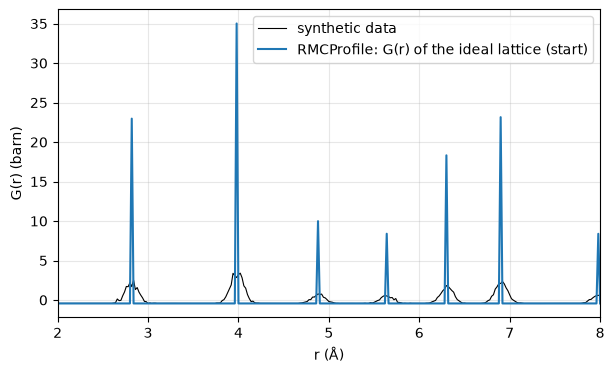

In [3]:
if not skip_without_package("the RMCProfile runs of this chapter"):
    res0 = rt.run_rmcprofile("nacl", WORK, PKG, timeout_min=3)
    print(f"rc={res0.returncode}, {res0.seconds:.1f} s, outputs: {', '.join(res0.outputs)}")
    print("final:", res0.final_chi2)
    x, calc, expt = rt.read_csv_pair(os.path.join(WORK, "nacl_PDF1.csv"))
    _, G_start = rt.total_gr(r, rt.partial_gr(cfg, rmax=8.0, dr=0.02)[1], cfg)
    n = len(x)
    check("RMCProfile ran the synthetic set (rc 0, chi2 row written)", res0.returncode == 0 and res0.final_chi2 is not None)
    check("the data column is our data file", np.allclose(expt, G_data[:n], atol=1e-4))
    check("RMCProfile's G(r) of the starting box equals the toolkit's", np.max(np.abs(calc - G_start[:n])) < 1e-3,
          f"max |diff| {np.max(np.abs(calc - G_start[:n])):.1e} barn")
    fig, ax = plt.subplots()
    ax.plot(x, expt, "k", lw=0.8, label="synthetic data")
    ax.plot(x, calc, label="RMCProfile: G(r) of the ideal lattice (start)")
    ax.set_xlim(2, 8); ax.set_xlabel("r (Å)"); ax.set_ylabel("G(r) (barn)"); ax.legend()
    show(fig)
    caption("Before any move: the synthetic G(r) 'data' (thermal box plus noise) against "
            "RMCProfile's calculated G(r) of the ideal-lattice starting box, read back from its "
            "_PDF1.csv. The delta-sharp lattice peaks must broaden into the data's.")

<a id="sec-16"></a>

## 16. The refinement

Half a minute of moves. RMCProfile reports every `PRINT_PERIOD` moves into `<stem>.chi2`
(`m_accepted m_generated m_tested chi2 …`), which `read_chi2_history` turns into arrays; the
fit itself is in `_PDF1.csv` and `_SQ1.csv`. After the run the calculated $G(r)$ sits on the
data, and the box the program saved (`nacl.rmc6f`, overwritten) has the thermal width put in.

Two traps the toolkit already defused: the `.his6f` the zero-move pass just wrote would be
read *instead of* the `.rmc6f` and, being empty, would make the program compute a constant
$G(r)$ and crawl (100 moves in 19 s in this book's tests) — `write_input_set` writes
`IGNORE_HISTORY_FILE ::` for that reason; and `SAVE_PERIOD :: 0.00` would save at every
print, so the save period is set to the time limit.

rc=0, 30 s; moves generated 25065, accepted 1765; chi2 1.623e+04 -> 11.06


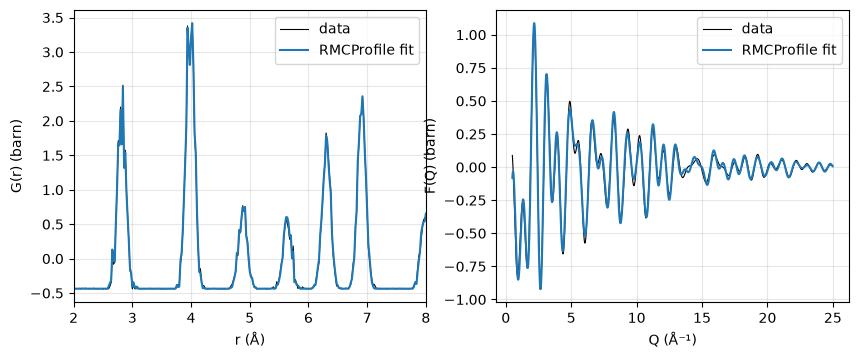

[PASS] chi2 decreased over the run — 1.623e+04 -> 11.06
[PASS] the fitted G(r) sits on the data (rms residual below ten times the 0.003 barn noise) — 0.0210 barn
[PASS] the refined box's Na–Cl shell has a thermal width (> 0.03 Å) — 0.074 Å


In [4]:
if not skip_without_package("the refinement"):
    dat = rt.read_dat(os.path.join(WORK, "nacl.dat"))
    dat.scalars["TIME_LIMIT"] = "0.50 MINUTES"
    dat.scalars["SAVE_PERIOD"] = "0.50 MINUTES"
    dat.write(os.path.join(WORK, "nacl.dat"))
    res = rt.run_rmcprofile("nacl", WORK, PKG, timeout_min=5)
    hist = rt.read_chi2_history(os.path.join(WORK, "nacl.chi2"))
    print(f"rc={res.returncode}, {res.seconds:.0f} s; moves generated {hist['m_generated'][-1]}, "
          f"accepted {hist['m_accepted'][-1]}; chi2 {hist['chi2'][0]:.4g} -> {hist['chi2'][-1]:.4g}")
    x, calc, expt = rt.read_csv_pair(os.path.join(WORK, "nacl_PDF1.csv"))
    xq, calcq, exptq = rt.read_csv_pair(os.path.join(WORK, "nacl_SQ1.csv"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    axes[0].plot(x, expt, "k", lw=0.8, label="data"); axes[0].plot(x, calc, label="RMCProfile fit")
    axes[0].set_xlim(2, 8); axes[0].set_xlabel("r (Å)"); axes[0].set_ylabel("G(r) (barn)"); axes[0].legend()
    axes[1].plot(xq, exptq, "k", lw=0.8, label="data"); axes[1].plot(xq, calcq, label="RMCProfile fit")
    axes[1].set_xlabel("Q (Å⁻¹)"); axes[1].set_ylabel("F(Q) (barn)"); axes[1].legend()
    show(fig)
    caption("After 30 s of RMCProfile moves on the synthetic NaCl set: the calculated G(r) "
            "(left) and F(Q) (right) against the data they were fitted to.")
    check("chi2 decreased over the run", hist["chi2"][-1] < 0.5 * hist["chi2"][0], f"{hist['chi2'][0]:.4g} -> {hist['chi2'][-1]:.4g}")
    resid = np.sqrt(np.mean((calc - expt) ** 2))
    check("the fitted G(r) sits on the data (rms residual below ten times the 0.003 barn noise)", resid < 0.03, f"{resid:.4f} barn")
    fitted = rt.read_rmc6f(os.path.join(WORK, "nacl.rmc6f"))
    r_f, g_f = rt.partial_gr(fitted, rmax=8.0, dr=0.02)
    shell = (r_f > 2.5) & (r_f < 3.2)
    width = np.sqrt(np.sum(g_f["Na-Cl"][shell] * (r_f[shell] - 2.82) ** 2) / np.sum(g_f["Na-Cl"][shell]))
    check("the refined box's Na–Cl shell has a thermal width (> 0.03 Å)", width > 0.03, f"{width:.3f} Å")

<a id="sec-17"></a>

## 17. `CONVOLVE ::` and the finite box

The model's $F(Q)$ is the transform of a $G(r)$ that stops at the half box; chapter 1 showed
the ripples this causes. `CONVOLVE ::` in a reciprocal-space block tells RMCProfile to apply
the same truncation to the *data* — convolve them with the transform of the box function —
so that model and data ring alike. Remove the keyword and the residual at high $Q$ rises.

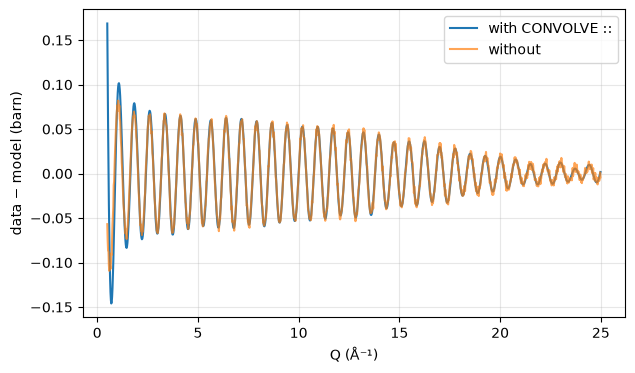

rms residual above 15 Å⁻¹: with CONVOLVE 0.0159, without 0.0161 barn
[PASS] CONVOLVE :: lowers the high-Q residual


In [5]:
if not skip_without_package("the CONVOLVE comparison"):
    def rerun(convolve):
        d = rt.read_dat(os.path.join(WORK, "nacl.dat"))
        blk = [b for b in d.blocks if b.name == "NEUTRON_RECIPROCAL_SPACE_DATA"][0]
        blk.items = [(k, v) for k, v in blk.items if k != "CONVOLVE"] + ([("CONVOLVE", "")] if convolve else [])
        d.scalars["TIME_LIMIT"] = "0.00 MINUTES"
        d.scalars["SAVE_PERIOD"] = "0.00 MINUTES"
        d.write(os.path.join(WORK, "nacl.dat"))
        rt.run_rmcprofile("nacl", WORK, PKG, timeout_min=3)
        xq, calcq, exptq = rt.read_csv_pair(os.path.join(WORK, "nacl_SQ1.csv"))
        hi = xq > 15
        return xq, calcq, exptq, np.sqrt(np.mean((calcq[hi] - exptq[hi]) ** 2))
    xq_c, calc_c, expt_c, res_c = rerun(True)
    xq_n, calc_n, expt_n, res_n = rerun(False)
    fig, ax = plt.subplots()
    ax.plot(xq_c, expt_c - calc_c, label="with CONVOLVE ::")
    ax.plot(xq_n, expt_n - calc_n, label="without", alpha=0.7)
    ax.set_xlabel("Q (Å⁻¹)"); ax.set_ylabel("data − model (barn)"); ax.legend()
    show(fig)
    caption("Residual of the reciprocal-space fit of the refined box with and without "
            "CONVOLVE ::. Without it the data keep their sharp features while the model, cut at "
            "the half box, rings — the residual at high Q grows.")
    print(f"rms residual above 15 Å⁻¹: with CONVOLVE {res_c:.4f}, without {res_n:.4f} barn")
    check("CONVOLVE :: lowers the high-Q residual", res_c < res_n)

<a id="sec-18"></a>

## 18. The same data through `rmclite`

The teaching engine fits the *partials*; RMCProfile fits the total functions. Give `rmclite`
the truth box's partials as targets and the two agree on the outcome — a box whose
$G(r)$ sits on the data — while differing in what they know: RMCProfile never sees the
partials, and its total $G(r)$ hides three partials behind one curve (chapter 1, §3).

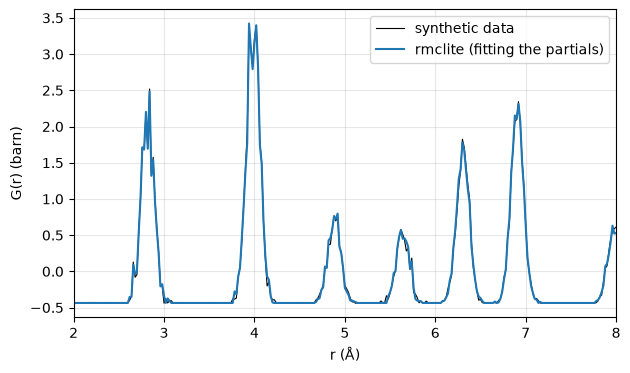

[PASS] rmclite's chi2 fell by > 95 % — 1.98e+06 -> 265
[PASS] rmclite's G(r) sits on the data too (rms below ten times the noise) — 0.0266 barn


True

In [6]:
start = rl.Box.from_rmc6f(cfg)
eng = rl.RmcLite(start, rmax=8.0, dr=0.02, targets=[rl.PartialTarget(lab, r, g_truth[lab], 0.2) for lab in g_truth],
                 constraints=[rl.ClosestApproach({"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0})],
                 max_move={"Na": 0.05, "Cl": 0.05}, seed=4)
c0 = eng.chi2
eng.run(8000)
_, G_lite = rt.total_gr(r, eng.hist.g(), cfg)
resid_lite = np.sqrt(np.mean((G_lite - G_data) ** 2))
fig, ax = plt.subplots()
ax.plot(r, G_data, "k", lw=0.8, label="synthetic data")
ax.plot(r, G_lite, label="rmclite (fitting the partials)")
ax.set_xlim(2, 8); ax.set_xlabel("r (Å)"); ax.set_ylabel("G(r) (barn)"); ax.legend()
show(fig)
caption("The same synthetic data reproduced by rmclite after 8000 moves from the ideal "
        "lattice; rmclite fitted the three partials, RMCProfile in §16 fitted the total G(r) "
        "and F(Q).")
check("rmclite's chi2 fell by > 95 %", eng.chi2 < 0.05 * c0, f"{c0:.3g} -> {eng.chi2:.3g}")
check("rmclite's G(r) sits on the data too (rms below ten times the noise)", resid_lite < 0.03, f"{resid_lite:.4f} barn")

### Exercises for chapter 4

**4.1** Rerun §16 with `WEIGHT :: 0.1` on the G(r) block (ten times looser). Does χ² end
lower or higher, and does the fitted G(r) sit closer to or farther from the data?

**4.2** Add a constant offset of 0.02 barn to the synthetic G(r) data. Evaluate the
starting box (`TIME_LIMIT 0`) with `CONSTANT_OFFSET :: 0.0000` and with `0.0200`: which χ²
is lower, and by how much?

In [7]:
if not skip_without_package("the exercises"):
    # 4.1 — chi2 is scaled by 1/sigma^2: a larger WEIGHT gives a smaller chi2 *number* for the same
    #       residual; the fit pushes less hard, so the residual itself is not smaller.
    d = rt.read_dat(os.path.join(WORK, "nacl.dat"))
    d.set("NEUTRON_REAL_SPACE_DATA", "WEIGHT", "0.1000")
    d.scalars["TIME_LIMIT"] = "0.25 MINUTES"
    d.write(os.path.join(WORK, "nacl.dat"))
    rt.run_rmcprofile("nacl", WORK, PKG, timeout_min=3)
    h = rt.read_chi2_history(os.path.join(WORK, "nacl.chi2"))
    x, calc, expt = rt.read_csv_pair(os.path.join(WORK, "nacl_PDF1.csv"))
    print(f"WEIGHT 0.1: chi2 {h['chi2'][0]:.4g} -> {h['chi2'][-1]:.4g}, rms residual {np.sqrt(np.mean((calc - expt) ** 2)):.4f} barn")
    check("4.1 a looser WEIGHT gives a smaller chi2 number for a comparable residual", h["chi2"][-1] < hist["chi2"][-1])

    # 4.2 — CONSTANT_OFFSET is added to the calculated function before comparison, so the value
    #       that matches the shift put into the data gives the lower chi2 for the same box.
    rt.write_data_file(os.path.join(WORK, "nacl_gr.dat"), r, G_data + 0.02, "offset data")
    chi = {}
    for off in ("0.0000", "0.0200"):
        d = rt.read_dat(os.path.join(WORK, "nacl.dat"))
        d.set("NEUTRON_REAL_SPACE_DATA", "CONSTANT_OFFSET", off)
        d.set("NEUTRON_REAL_SPACE_DATA", "WEIGHT", "0.0100")
        d.scalars["TIME_LIMIT"] = "0.00 MINUTES"
        d.scalars["SAVE_PERIOD"] = "0.00 MINUTES"
        d.write(os.path.join(WORK, "nacl.dat"))
        res = rt.run_rmcprofile("nacl", WORK, PKG, timeout_min=3)
        chi[off] = res.final_chi2["Expt_1"]
        print(f"CONSTANT_OFFSET {off}: Expt_1 chi2 {chi[off]:.4g}")
    check("4.2 the offset that matches the data gives the lower chi2", chi["0.0200"] < chi["0.0000"])

WEIGHT 0.1: chi2 8.606 -> 8.606, rms residual 0.0505 barn
[PASS] 4.1 a looser WEIGHT gives a smaller chi2 number for a comparable residual


CONSTANT_OFFSET 0.0000: Expt_1 chi2 29.4


CONSTANT_OFFSET 0.0200: Expt_1 chi2 25.51
[PASS] 4.2 the offset that matches the data gives the lower chi2


In [8]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 4 — checks passed : {_CHECKS['pass']}")
print(f"chapter 4 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 4 — checks passed : 13
chapter 4 — checks failed : 0
wall time                 : 62 s
Every quantitative claim in this notebook was verified in this run.
